# Загрузка метаданных FMA для обучения модели XGBoost

## Загрузка данных

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
import time
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path.cwd().parent))

import xgboost as xgb
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)

from src.data.load_processed import load_data
from src.data.config import paths

print("✅ Библиотеки загружены")
print(f"XGBoost version: {xgb.__version__}")

✅ Библиотеки загружены
XGBoost version: 3.2.0


In [3]:
print("="*60)
print("ЗАГРУЗКА ПОДГОТОВЛЕННЫХ ДАННЫХ")
print("="*60)

data = load_data(
    subset="medium",
    min_samples_per_genre=100,
    as_dataframe=False
)

X_train = data['X_train']
X_val = data['X_val']
X_test = data['X_test']
y_train = data['y_train']
y_val = data['y_val']
y_test = data['y_test']
genre_names = data['genre_names']
metadata = data['metadata']

print(f"\n📊 Размеры выборок:")
print(f"  Train: {X_train.shape} (признаков: {X_train.shape[1]})")
print(f"  Val:   {X_val.shape}")
print(f"  Test:  {X_test.shape}")
print(f"\n🎵 Количество жанров: {len(genre_names)}")
print(f"  Жанры: {', '.join(genre_names)}")
print(f"\n📈 Распределение меток в train:")
unique, counts = np.unique(y_train, return_counts=True)
for genre_id, genre_name, count in zip(unique, genre_names, counts):
    print(f"  {genre_name:15s}: {count} треков ({count/len(y_train)*100:.1f}%)")

ЗАГРУЗКА ПОДГОТОВЛЕННЫХ ДАННЫХ
Загрузка данных из D:\Projects\PythonProject\music-genre-classification-fma\data\processed...
✅ Загружены данные: 19922 train, 2505 val, 2573 test
   Жанров: 16

📊 Размеры выборок:
  Train: (19922, 518) (признаков: 518)
  Val:   (2505, 518)
  Test:  (2573, 518)

🎵 Количество жанров: 16
  Жанры: Blues, Classical, Country, Easy Listening, Electronic, Experimental, Folk, Hip-Hop, Instrumental, International, Jazz, Old-Time / Historic, Pop, Rock, Soul-RnB, Spoken

📈 Распределение меток в train:
  Blues          : 58 треков (0.3%)
  Classical      : 495 треков (2.5%)
  Country        : 142 треков (0.7%)
  Easy Listening : 13 треков (0.1%)
  Electronic     : 5050 треков (25.3%)
  Experimental   : 1801 треков (9.0%)
  Folk           : 1215 треков (6.1%)
  Hip-Hop        : 1761 треков (8.8%)
  Instrumental   : 1045 треков (5.2%)
  International  : 814 треков (4.1%)
  Jazz           : 306 треков (1.5%)
  Old-Time / Historic: 408 треков (2.0%)
  Pop            : 94

## XGBoost (моно-классификация)

In [4]:
# DEFAULT PARAMS
print("="*60)
print("БАЗОВАЯ МОДЕЛЬ XGBOOST (DEFAULT PARAMS)")
print("="*60)

model_default = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.3,
    objective='multi:softmax',
    num_class=len(genre_names),
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

start_time = time.time()

model_default.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

train_time = time.time() - start_time

y_pred_default = model_default.predict(X_test)
y_pred_proba_default = model_default.predict_proba(X_test)

acc_default = accuracy_score(y_test, y_pred_default)
f1_macro_default = f1_score(y_test, y_pred_default, average='macro')
f1_weighted_default = f1_score(y_test, y_pred_default, average='weighted')

print(f"\n📊 Результаты:")
print(f"  Время обучения: {train_time:.2f} сек")
print(f"  Accuracy:      {acc_default:.4f}")
print(f"  F1 (macro):    {f1_macro_default:.4f}")
print(f"  F1 (weighted): {f1_weighted_default:.4f}")

print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred_default, target_names=genre_names))

БАЗОВАЯ МОДЕЛЬ XGBOOST (DEFAULT PARAMS)

📊 Результаты:
  Время обучения: 163.25 сек
  Accuracy:      0.6308
  F1 (macro):    0.3975
  F1 (weighted): 0.5944

📋 Classification Report:
                     precision    recall  f1-score   support

              Blues       0.00      0.00      0.00         8
          Classical       0.73      0.65      0.68        62
            Country       0.00      0.00      0.00        18
     Easy Listening       0.00      0.00      0.00         6
         Electronic       0.63      0.85      0.73       632
       Experimental       0.41      0.36      0.39       225
               Folk       0.34      0.28      0.31       152
            Hip-Hop       0.80      0.61      0.69       220
       Instrumental       0.51      0.28      0.36       174
      International       0.69      0.28      0.40       102
               Jazz       0.68      0.38      0.49        39
Old-Time / Historic       0.93      0.98      0.95        51
                Pop     

In [5]:
# BALANCED
print("="*60)
print("XGBOOST С ВЕСАМИ КЛАССОВ (BALANCED)")
print("="*60)

from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
weight_dict = dict(zip(np.unique(y_train), class_weights))

print(f"Веса классов:")
for i, genre in enumerate(genre_names):
    print(f"  {genre:15s}: {weight_dict[i]:.3f}")

sample_weights = np.array([weight_dict[y] for y in y_train])

model_weighted = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.3,
    objective='multi:softmax',
    num_class=len(genre_names),
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

start_time = time.time()
model_weighted.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_val, y_val)],
    verbose=False
)
train_time = time.time() - start_time

y_pred_weighted = model_weighted.predict(X_test)

acc_weighted = accuracy_score(y_test, y_pred_weighted)
f1_macro_weighted = f1_score(y_test, y_pred_weighted, average='macro')
f1_weighted_weighted = f1_score(y_test, y_pred_weighted, average='weighted')

print(f"\n📊 Результаты:")
print(f"  Время обучения: {train_time:.2f} сек")
print(f"  Accuracy:      {acc_weighted:.4f}")
print(f"  F1 (macro):    {f1_macro_weighted:.4f}")
print(f"  F1 (weighted): {f1_weighted_weighted:.4f}")

XGBOOST С ВЕСАМИ КЛАССОВ (BALANCED)
Веса классов:
  Blues          : 21.468
  Classical      : 2.515
  Country        : 8.768
  Easy Listening : 95.779
  Electronic     : 0.247
  Experimental   : 0.691
  Folk           : 1.025
  Hip-Hop        : 0.707
  Instrumental   : 1.192
  International  : 1.530
  Jazz           : 4.069
  Old-Time / Historic: 3.052
  Pop            : 1.318
  Rock           : 0.219
  Soul-RnB       : 13.246
  Spoken         : 13.246

📊 Результаты:
  Время обучения: 161.92 сек
  Accuracy:      0.6238
  F1 (macro):    0.4144
  F1 (weighted): 0.6004


In [10]:
# max_depth
print("="*60)
print("ЭКСПЕРИМЕНТ: ВЛИЯНИЕ max_depth")
print("="*60)

depths = [3, 5, 7, 9, 11]
results_depth = []

from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
weight_dict = dict(zip(np.unique(y_train), class_weights))
sample_weights = np.array([weight_dict[y] for y in y_train])

for depth in depths:
    print(f"\n📊 max_depth = {depth}")

    model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=depth,
        learning_rate=0.3,
        objective='multi:softmax',
        num_class=len(genre_names),
        random_state=42,
        n_jobs=-1,
        eval_metric='mlogloss'
    )

    start_time = time.time()
    model.fit(
        X_train, y_train,
        sample_weight=sample_weights,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    train_time = time.time() - start_time

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')

    results_depth.append({
        'max_depth': depth,
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'train_time': train_time
    })

    print(f"  Accuracy: {acc:.4f}, F1-macro: {f1_macro:.4f}, F1-weighted: {f1_weighted:.4f}, Time: {train_time:.2f}s")

print("\n" + "="*60)
print("СВОДНАЯ ТАБЛИЦА: max_depth")
results_depth_df = pd.DataFrame(results_depth)
print(results_depth_df.to_string(index=False))

ЭКСПЕРИМЕНТ: ВЛИЯНИЕ max_depth

📊 max_depth = 3
  Accuracy: 0.5942, F1-macro: 0.4112, F1-weighted: 0.6025, Time: 62.49s

📊 max_depth = 5
  Accuracy: 0.6304, F1-macro: 0.4213, F1-weighted: 0.6159, Time: 103.03s

📊 max_depth = 7
  Accuracy: 0.6312, F1-macro: 0.4113, F1-weighted: 0.6053, Time: 170.88s

📊 max_depth = 9
  Accuracy: 0.6250, F1-macro: 0.4043, F1-weighted: 0.5971, Time: 214.69s

📊 max_depth = 11
  Accuracy: 0.6277, F1-macro: 0.4091, F1-weighted: 0.6009, Time: 229.91s

СВОДНАЯ ТАБЛИЦА: max_depth
 max_depth  accuracy  f1_macro  f1_weighted  train_time
         3  0.594248  0.411227     0.602549   62.492733
         5  0.630393  0.421276     0.615866  103.031471
         7  0.631170  0.411344     0.605271  170.878916
         9  0.624951  0.404329     0.597068  214.688298
        11  0.627672  0.409060     0.600897  229.906803


In [11]:
# n_estimators
print("="*60)
print("ЭКСПЕРИМЕНТ: ВЛИЯНИЕ n_estimators")
print("="*60)

estimators_list = [50, 100, 150, 200, 300]
results_estimators = []

from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
weight_dict = dict(zip(np.unique(y_train), class_weights))
sample_weights = np.array([weight_dict[y] for y in y_train])

for estimators in estimators_list:
    print(f"\n📊 n_estimators = {estimators}")

    model = xgb.XGBClassifier(
        n_estimators=estimators,
        max_depth=5,
        learning_rate=0.3,
        objective='multi:softmax',
        num_class=len(genre_names),
        random_state=42,
        n_jobs=-1,
        eval_metric='mlogloss'
    )

    start_time = time.time()
    model.fit(
        X_train, y_train,
        sample_weight=sample_weights,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    train_time = time.time() - start_time

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')

    results_estimators.append({
        'n_estimators': estimators,
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'train_time': train_time
    })

    print(f"  Accuracy: {acc:.4f}, F1-macro: {f1_macro:.4f}, F1-weighted: {f1_weighted:.4f}, Time: {train_time:.2f}s")

print("\n" + "="*60)
print("СВОДНАЯ ТАБЛИЦА: n_estimators")
results_estimators_df = pd.DataFrame(results_estimators)
print(results_estimators_df.to_string(index=False))

ЭКСПЕРИМЕНТ: ВЛИЯНИЕ n_estimators

📊 n_estimators = 50
  Accuracy: 0.6059, F1-macro: 0.4039, F1-weighted: 0.6029, Time: 52.46s

📊 n_estimators = 100
  Accuracy: 0.6304, F1-macro: 0.4213, F1-weighted: 0.6159, Time: 98.40s

📊 n_estimators = 150
  Accuracy: 0.6354, F1-macro: 0.4131, F1-weighted: 0.6161, Time: 141.95s

📊 n_estimators = 200
  Accuracy: 0.6378, F1-macro: 0.4064, F1-weighted: 0.6157, Time: 174.42s

📊 n_estimators = 300
  Accuracy: 0.6389, F1-macro: 0.4117, F1-weighted: 0.6139, Time: 277.29s

СВОДНАЯ ТАБЛИЦА: n_estimators
 n_estimators  accuracy  f1_macro  f1_weighted  train_time
           50  0.605908  0.403887     0.602938   52.462281
          100  0.630393  0.421276     0.615866   98.395928
          150  0.635445  0.413058     0.616095  141.949643
          200  0.637777  0.406404     0.615738  174.422449
          300  0.638943  0.411656     0.613860  277.288803


In [12]:
# learning_rate
print("="*60)
print("ЭКСПЕРИМЕНТ: ВЛИЯНИЕ learning_rate")
print("="*60)

learning_rates = [0.01, 0.05, 0.1, 0.2, 0.3]
results_lr = []

from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
weight_dict = dict(zip(np.unique(y_train), class_weights))
sample_weights = np.array([weight_dict[y] for y in y_train])

for lr in learning_rates:
    print(f"\n📊 learning_rate = {lr}")

    model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=lr,
        objective='multi:softmax',
        num_class=len(genre_names),
        random_state=42,
        n_jobs=-1,
        eval_metric='mlogloss'
    )

    start_time = time.time()
    model.fit(
        X_train, y_train,
        sample_weight=sample_weights,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    train_time = time.time() - start_time

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')

    results_lr.append({
        'learning_rate': lr,
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'train_time': train_time
    })

    print(f"  Accuracy: {acc:.4f}, F1-macro: {f1_macro:.4f}, F1-weighted: {f1_weighted:.4f}, Time: {train_time:.2f}s")

print("\n" + "="*60)
print("СВОДНАЯ ТАБЛИЦА: learning_rate")
results_lr_df = pd.DataFrame(results_lr)
print(results_lr_df.to_string(index=False))

ЭКСПЕРИМЕНТ: ВЛИЯНИЕ learning_rate

📊 learning_rate = 0.01
  Accuracy: 0.5223, F1-macro: 0.3587, F1-weighted: 0.5349, Time: 121.98s

📊 learning_rate = 0.05
  Accuracy: 0.5861, F1-macro: 0.4160, F1-weighted: 0.5907, Time: 113.43s

📊 learning_rate = 0.1
  Accuracy: 0.6141, F1-macro: 0.4107, F1-weighted: 0.6129, Time: 103.60s

📊 learning_rate = 0.2
  Accuracy: 0.6222, F1-macro: 0.4008, F1-weighted: 0.6118, Time: 102.90s

📊 learning_rate = 0.3
  Accuracy: 0.6304, F1-macro: 0.4213, F1-weighted: 0.6159, Time: 115.36s

СВОДНАЯ ТАБЛИЦА: learning_rate
 learning_rate  accuracy  f1_macro  f1_weighted  train_time
          0.01  0.522347  0.358667     0.534865  121.982960
          0.05  0.586086  0.415993     0.590676  113.431077
          0.10  0.614069  0.410745     0.612920  103.599306
          0.20  0.622231  0.400759     0.611843  102.897129
          0.30  0.630393  0.421276     0.615866  115.355604


In [13]:
# BEST BY EXPERIMENTS
print("="*60)
print("ОПТИМАЛЬНАЯ МОДЕЛЬ XGBOOST")
print("="*60)

best_params = {
    'n_estimators': 100,
    'max_depth': 5,
    'learning_rate': 0.3,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 3,
    'reg_alpha': 0.1,
    'reg_lambda': 1
}

print("Используемые параметры:")
for key, value in best_params.items():
    print(f"  {key}: {value}")

from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
weight_dict = dict(zip(np.unique(y_train), class_weights))

print(f"Веса классов:")
for i, genre in enumerate(genre_names):
    print(f"  {genre:15s}: {weight_dict[i]:.3f}")

sample_weights = np.array([weight_dict[y] for y in y_train])

model_best = xgb.XGBClassifier(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    learning_rate=best_params['learning_rate'],
    subsample=best_params['subsample'],
    colsample_bytree=best_params['colsample_bytree'],
    min_child_weight=best_params['min_child_weight'],
    reg_alpha=best_params['reg_alpha'],
    reg_lambda=best_params['reg_lambda'],
    objective='multi:softmax',
    num_class=len(genre_names),
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

start_time = time.time()
model_best.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_val, y_val)],
    verbose=False
)
train_time = time.time() - start_time

y_pred_best = model_best.predict(X_test)
y_pred_proba_best = model_best.predict_proba(X_test)

acc_best = accuracy_score(y_test, y_pred_best)
prec_best = precision_score(y_test, y_pred_best, average='weighted')
rec_best = recall_score(y_test, y_pred_best, average='weighted')
f1_best = f1_score(y_test, y_pred_best, average='weighted')
f1_macro_best = f1_score(y_test, y_pred_best, average='macro')

print(f"\n📊 Результаты оптимальной модели:")
print(f"  Время обучения: {train_time:.2f} сек")
print(f"  Accuracy:       {acc_best:.4f}")
print(f"  Precision (w):  {prec_best:.4f}")
print(f"  Recall (w):     {rec_best:.4f}")
print(f"  F1 (weighted):  {f1_best:.4f}")
print(f"  F1 (macro):     {f1_macro_best:.4f}")

print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=genre_names))

ОПТИМАЛЬНАЯ МОДЕЛЬ XGBOOST
Используемые параметры:
  n_estimators: 100
  max_depth: 5
  learning_rate: 0.3
  subsample: 0.8
  colsample_bytree: 0.8
  min_child_weight: 3
  reg_alpha: 0.1
  reg_lambda: 1
Веса классов:
  Blues          : 21.468
  Classical      : 2.515
  Country        : 8.768
  Easy Listening : 95.779
  Electronic     : 0.247
  Experimental   : 0.691
  Folk           : 1.025
  Hip-Hop        : 0.707
  Instrumental   : 1.192
  International  : 1.530
  Jazz           : 4.069
  Old-Time / Historic: 3.052
  Pop            : 1.318
  Rock           : 0.219
  Soul-RnB       : 13.246
  Spoken         : 13.246

📊 Результаты оптимальной модели:
  Время обучения: 109.13 сек
  Accuracy:       0.6218
  Precision (w):  0.6052
  Recall (w):     0.6218
  F1 (weighted):  0.6104
  F1 (macro):     0.4253

📋 Classification Report:
                     precision    recall  f1-score   support

              Blues       0.00      0.00      0.00         8
          Classical       0.80      0.

## Результаты

ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ


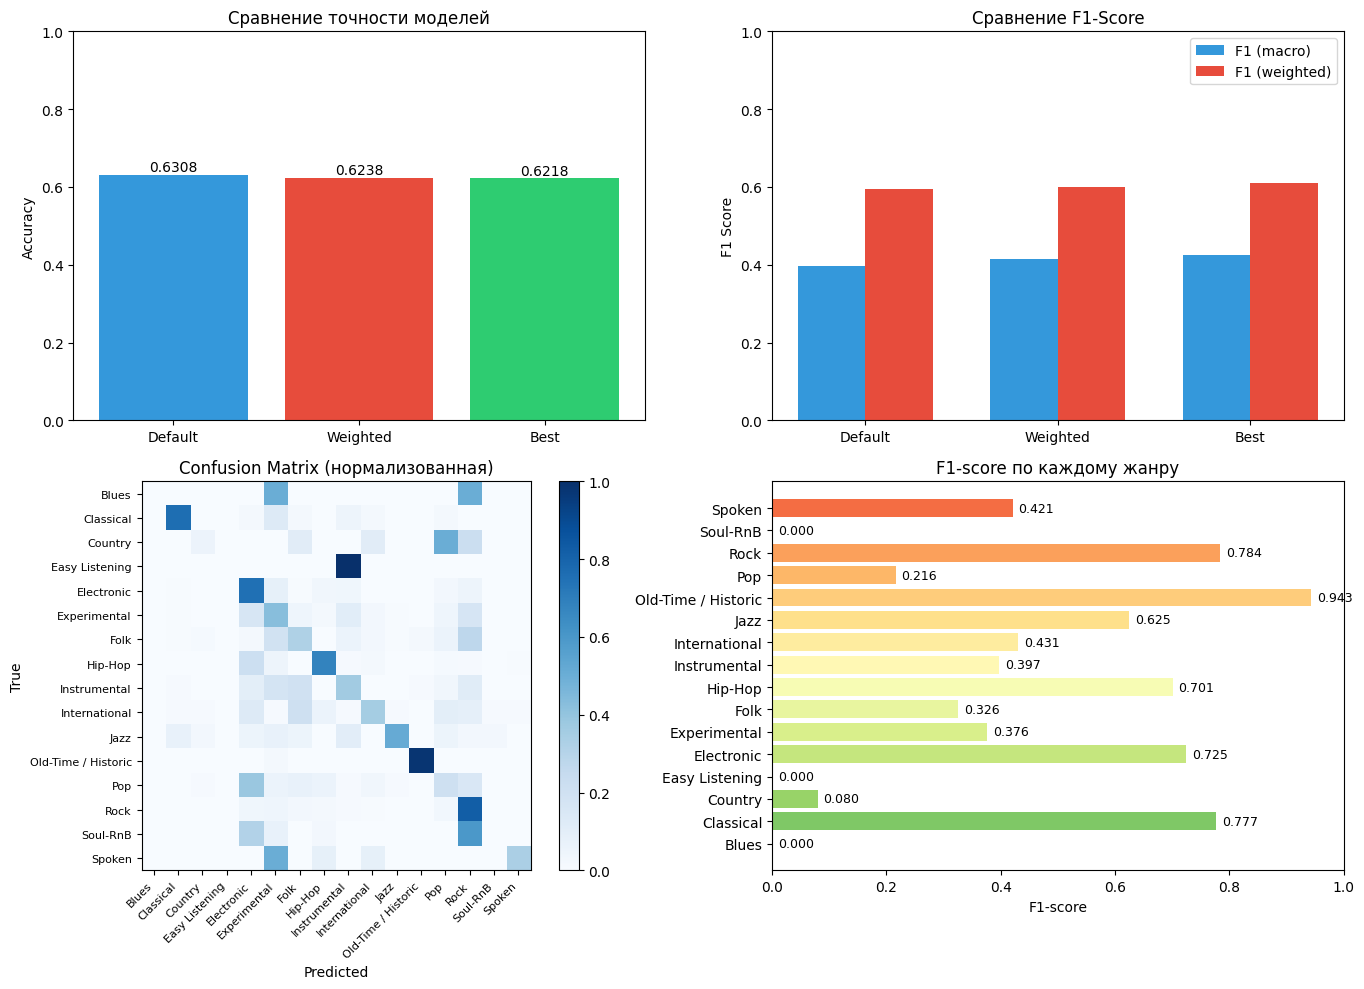

✅ Визуализация сохранена в D:\Projects\PythonProject\music-genre-classification-fma\results\xgboost_results.png


In [14]:
# ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
print("="*60)
print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]
models_names = ['Default', 'Weighted', 'Best']
accuracies = [acc_default, acc_weighted, acc_best]
colors = ['#3498db', '#e74c3c', '#2ecc71']
bars = ax1.bar(models_names, accuracies, color=colors)
ax1.set_ylabel('Accuracy')
ax1.set_title('Сравнение точности моделей')
ax1.set_ylim([0, 1])
for bar, acc in zip(bars, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.4f}', ha='center', fontsize=10)

ax2 = axes[0, 1]
x = np.arange(len(models_names))
width = 0.35
f1_macro_vals = [f1_macro_default, f1_macro_weighted, f1_macro_best]
f1_weighted_vals = [f1_weighted_default, f1_weighted_weighted, f1_best]
ax2.bar(x - width/2, f1_macro_vals, width, label='F1 (macro)', color='#3498db')
ax2.bar(x + width/2, f1_weighted_vals, width, label='F1 (weighted)', color='#e74c3c')
ax2.set_xticks(x)
ax2.set_xticklabels(models_names)
ax2.set_ylabel('F1 Score')
ax2.set_title('Сравнение F1-Score')
ax2.legend()
ax2.set_ylim([0, 1])

ax3 = axes[1, 0]
cm = confusion_matrix(y_test, y_pred_best)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
im = ax3.imshow(cm_norm, interpolation='nearest', cmap='Blues')
ax3.set_xticks(np.arange(len(genre_names)))
ax3.set_yticks(np.arange(len(genre_names)))
ax3.set_xticklabels(genre_names, rotation=45, ha='right', fontsize=8)
ax3.set_yticklabels(genre_names, fontsize=8)
ax3.set_xlabel('Predicted')
ax3.set_ylabel('True')
ax3.set_title('Confusion Matrix (нормализованная)')
plt.colorbar(im, ax=ax3)

ax4 = axes[1, 1]
report_dict = classification_report(y_test, y_pred_best, target_names=genre_names, output_dict=True)
f1_per_class = [report_dict[genre]['f1-score'] for genre in genre_names]
colors_red = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(genre_names)))
bars = ax4.barh(genre_names, f1_per_class, color=colors_red)
ax4.set_xlabel('F1-score')
ax4.set_title('F1-score по каждому жанру')
ax4.set_xlim([0, 1])
for bar, score in zip(bars, f1_per_class):
    ax4.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{score:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(paths.results_dir / 'xgboost_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Визуализация сохранена в", paths.results_dir / 'xgboost_results.png')

АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ


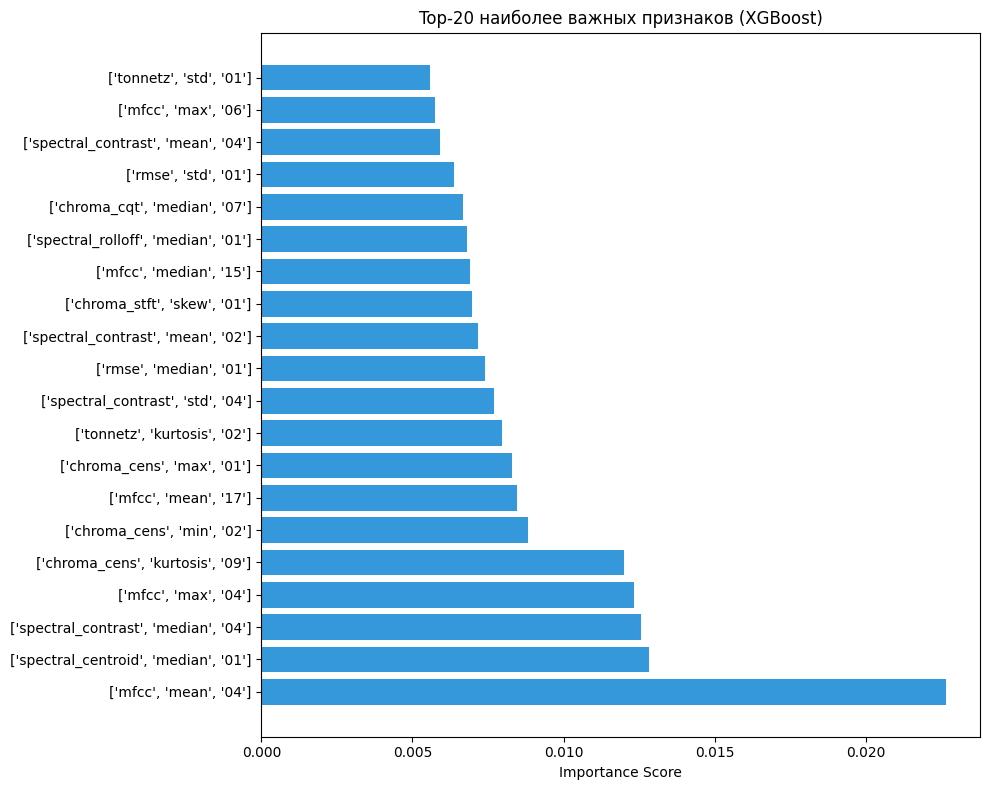


✅ Топ-5 признаков:
  1. ['mfcc', 'mean', '04']: 0.0226
  2. ['spectral_centroid', 'median', '01']: 0.0128
  3. ['spectral_contrast', 'median', '04']: 0.0126
  4. ['mfcc', 'max', '04']: 0.0123
  5. ['chroma_cens', 'kurtosis', '09']: 0.0120


In [15]:
# АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ
print("="*60)
print("АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ")
print("="*60)

feature_importance = model_best.feature_importances_
feature_names = metadata.get('feature_names')

if feature_names is None or len(feature_names) != len(feature_importance):
    feature_names = [f'feature_{i}' for i in range(len(feature_importance))]

sorted_idx = np.argsort(feature_importance)[::-1]
top_n = 20

fig, ax = plt.subplots(figsize=(10, 8))
top_features = [feature_names[i] for i in sorted_idx[:top_n]]
top_importances = feature_importance[sorted_idx[:top_n]]

short_names = [name if len(str(name)) < 40 else str(name)[:37] + '...' for name in top_features]

bars = ax.barh(range(top_n), top_importances[::-1], color='#3498db')
ax.set_yticks(range(top_n))
ax.set_yticklabels(short_names[::-1])
ax.set_xlabel('Importance Score')
ax.set_title(f'Top-{top_n} наиболее важных признаков (XGBoost)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(paths.results_dir / 'xgboost_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Топ-5 признаков:")
for i in range(min(5, top_n)):
    print(f"  {i+1}. {short_names[i]}: {top_importances[i]:.4f}")

In [16]:
# СВОДНАЯ ТАБЛИЦА ВСЕХ ЭКСПЕРИМЕНТОВ
print("="*60)
print("СВОДНАЯ ТАБЛИЦА ВСЕХ ЭКСПЕРИМЕНТОВ")
print("="*60)

summary = pd.DataFrame([
    {'model': 'Default (baseline)', 'accuracy': acc_default, 'f1_macro': f1_macro_default},
    {'model': 'Weighted classes', 'accuracy': acc_weighted, 'f1_macro': f1_macro_weighted},
    {'model': 'Optimal (best)', 'accuracy': acc_best, 'f1_macro': f1_macro_best}
])

best_depth = max(results_depth, key=lambda x: x['accuracy'])
best_estimators = max(results_estimators, key=lambda x: x['accuracy'])
best_lr = max(results_lr, key=lambda x: x['accuracy'])

summary = pd.concat([
    summary,
    pd.DataFrame([
        {'model': f"Best max_depth={best_depth['max_depth']}", 'accuracy': best_depth['accuracy'], 'f1_macro': best_depth['f1_macro']},
        {'model': f"Best n_estimators={best_estimators['n_estimators']}", 'accuracy': best_estimators['accuracy'], 'f1_macro': best_estimators['f1_macro']},
        {'model': f"Best lr={best_lr['learning_rate']}", 'accuracy': best_lr['accuracy'], 'f1_macro': best_lr['f1_macro']}
    ])
])

print(summary.to_string(index=False))
print(f"\n🏆 Лучшая модель: {summary.loc[summary['accuracy'].idxmax(), 'model']}")
print(f"   Accuracy: {summary['accuracy'].max():.4f}")

СВОДНАЯ ТАБЛИЦА ВСЕХ ЭКСПЕРИМЕНТОВ
                model  accuracy  f1_macro
   Default (baseline)  0.630781  0.397455
     Weighted classes  0.623785  0.414386
       Optimal (best)  0.621842  0.425255
     Best max_depth=7  0.631170  0.411344
Best n_estimators=300  0.638943  0.411656
          Best lr=0.3  0.630393  0.421276

🏆 Лучшая модель: 1         Weighted classes
1    Best n_estimators=300
Name: model, dtype: str
   Accuracy: 0.6389


In [17]:
# СОХРАНЕНИЕ МОДЕЛИ И РЕЗУЛЬТАТОВ
print("="*60)
print("СОХРАНЕНИЕ МОДЕЛИ И РЕЗУЛЬТАТОВ")
print("="*60)

model_path = paths.models_dir / "xgboost_best.json"
model_path.parent.mkdir(parents=True, exist_ok=True)
model_best.save_model(str(model_path))
print(f"✅ Модель сохранена: {model_path}")

results = {
    'model_name': 'XGBoost',
    'dataset': 'FMA Medium',
    'num_classes': len(genre_names),
    'genre_names': genre_names,
    'parameters': best_params,
    'metrics': {
        'accuracy': float(acc_best),
        'precision_weighted': float(prec_best),
        'recall_weighted': float(rec_best),
        'f1_weighted': float(f1_best),
        'f1_macro': float(f1_macro_best)
    },
    'class_metrics': classification_report(y_test, y_pred_best, output_dict=True),
    'train_time_seconds': train_time,
    'experiments': {
        'max_depth': results_depth,
        'n_estimators': results_estimators,
        'learning_rate': results_lr
    }
}

results_path = paths.results_dir / "xgboost_baseline_results.json"
with open(results_path, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print(f"✅ Результаты сохранены: {results_path}")

print("\n📊 ФИНАЛЬНЫЕ МЕТРИКИ ЛУЧШЕЙ МОДЕЛИ:")
print("="*40)
print(f"  Accuracy:      {acc_best:.4f} ({acc_best*100:.2f}%)")
print(f"  Precision (w): {prec_best:.4f}")
print(f"  Recall (w):    {rec_best:.4f}")
print(f"  F1 (weighted): {f1_best:.4f}")
print(f"  F1 (macro):    {f1_macro_best:.4f}")
print("="*40)

СОХРАНЕНИЕ МОДЕЛИ И РЕЗУЛЬТАТОВ
✅ Модель сохранена: D:\Projects\PythonProject\music-genre-classification-fma\models\xgboost_best.json
✅ Результаты сохранены: D:\Projects\PythonProject\music-genre-classification-fma\results\xgboost_baseline_results.json

📊 ФИНАЛЬНЫЕ МЕТРИКИ ЛУЧШЕЙ МОДЕЛИ:
  Accuracy:      0.6218 (62.18%)
  Precision (w): 0.6052
  Recall (w):    0.6218
  F1 (weighted): 0.6104
  F1 (macro):    0.4253
